In [3]:
import pandas as pd
df = pd.read_csv('events.csv')
df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [4]:
print(df.shape)
df['event'].value_counts()

(2756101, 5)


event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [5]:
views = 2664312
carts = 69332
purchase = 22457

view_to_cart = (carts / views) * 100
cart_to_purchase = (purchase / carts) * 100
view_to_purchase = (purchase / views) * 100

print(f"View to Cart: {view_to_cart:.2f}%")
print(f"Cart to Purchase: {cart_to_purchase:.2f}%")
print(f"Overall View to Purchase: {view_to_purchase:.2f}%")

View to Cart: 2.60%
Cart to Purchase: 32.39%
Overall View to Purchase: 0.84%


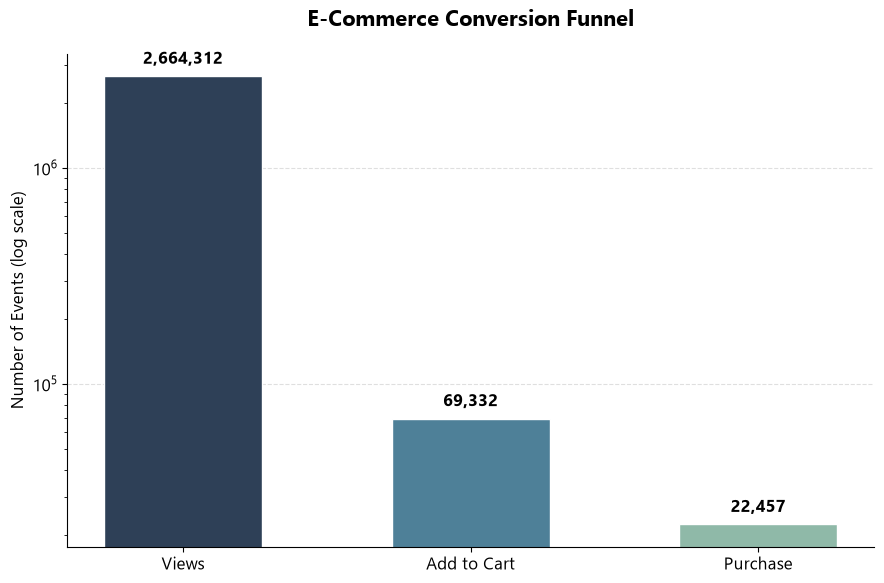

In [8]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Segoe UI'
plt.rcParams['font.size'] = 12

stages = ['Views', 'Add to Cart', 'Purchase']
values = [views, carts, purchase]
colors = ['#2E4057', '#4E8098', '#8FB9A8']

fig, ax = plt.subplots(figsize=(9, 6))
bars =ax.bar(stages, values, color=colors, width=0.55, edgecolor='white')
ax.set_yscale('log')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height * 1.1,
             f'{height:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('E-Commerce Conversion Funnel', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Number of Events (log scale)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--',alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

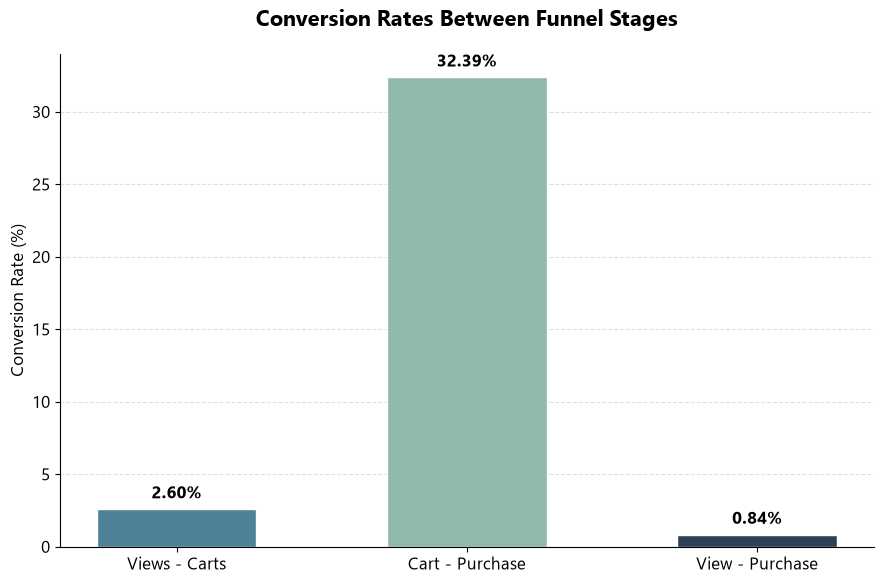

In [11]:
stages_conv = ['Views - Carts', 'Cart - Purchase', 'View - Purchase']
rates = [view_to_cart, cart_to_purchase, view_to_purchase]

fig, ax = plt.subplots(figsize=(9, 6))
bars2 = ax.bar(stages_conv, rates, color=['#4E8098', '#8FB9A8', '#2E4057'], width=0.55, edgecolor='white')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Conversion Rates Between Funnel Stages', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

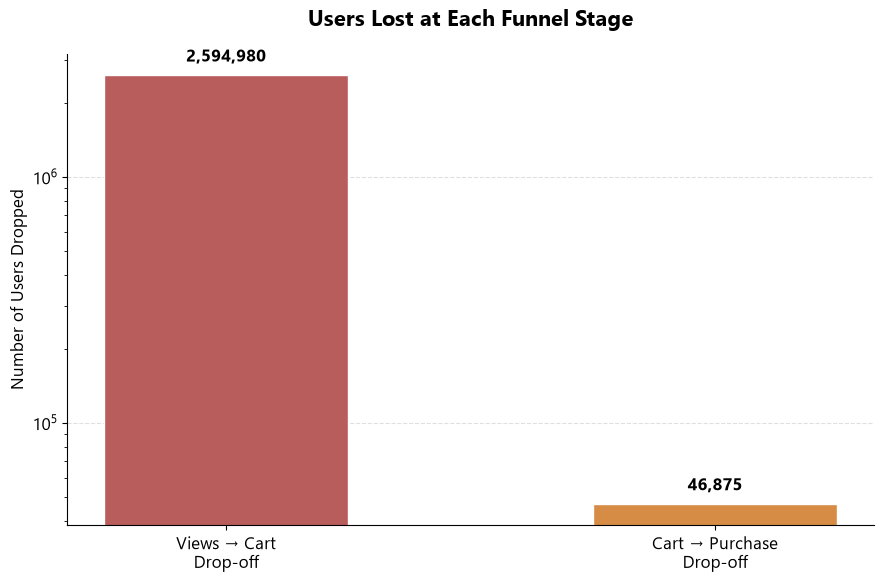

In [13]:
dropoff_view_cart = views - carts
dropoff_cart_purchase = carts - purchase

stages_drop = ['Views → Cart\nDrop-off', 'Cart → Purchase\nDrop-off']
dropoffs = [dropoff_view_cart, dropoff_cart_purchase]

fig, ax = plt.subplots(figsize=(9, 6))
bars3 = ax.bar(stages_drop, dropoffs, color=['#B85C5C', '#D68C45'], width=0.5, edgecolor='white')
ax.set_yscale('log')

for bar in bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height * 1.1,
             f'{height:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Users Lost at Each Funnel Stage', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Number of Users Dropped', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

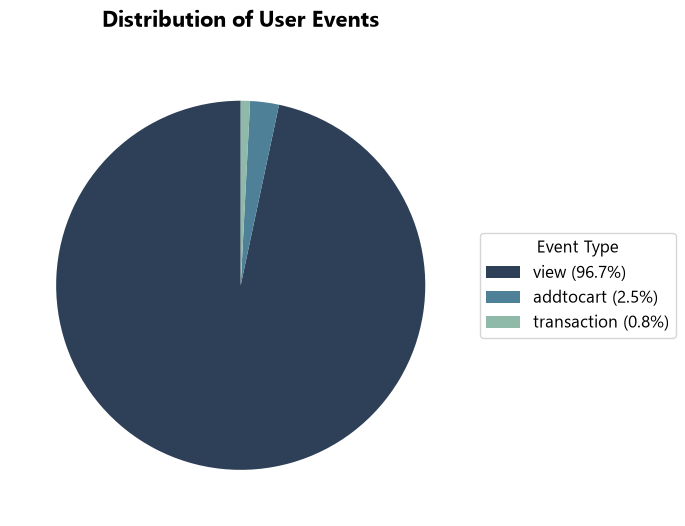

In [16]:
event_counts = df['event'].value_counts()
percentages = (event_counts / event_counts.sum() * 100).round(1)
legend_labels = [f'{name} ({pct}%)' for name, pct in zip(event_counts.index, percentages)]

fig, ax = plt.subplots(figsize=(7, 7))
colors_pie = ['#2E4057', '#4E8098', '#8FB9A8']
wedges, texts = ax.pie(event_counts, colors=colors_pie, startangle=90)

ax.legend(wedges, legend_labels, title='Event Type', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
ax.set_title('Distribution of User Events', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

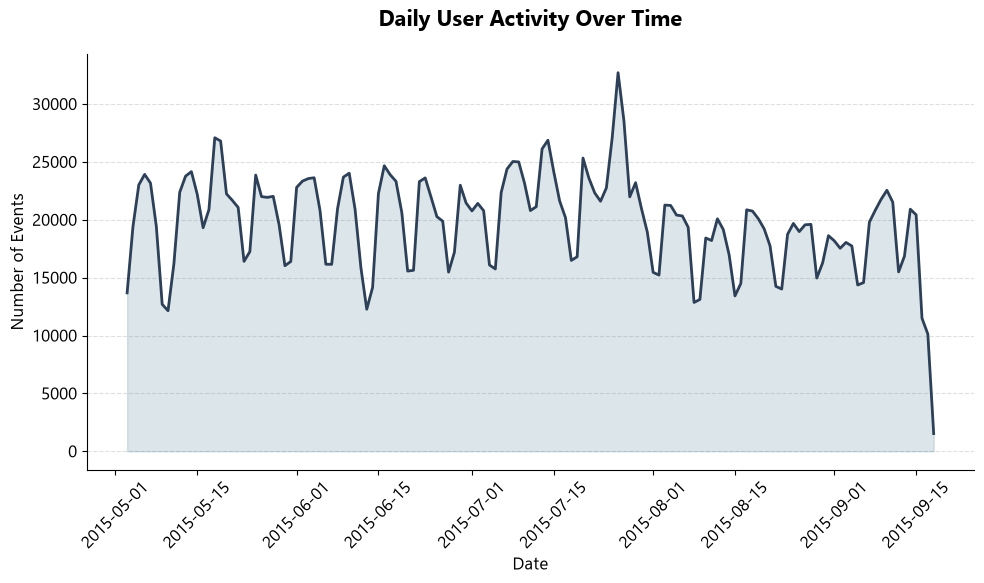

In [17]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df['date'] = df['datetime'].dt.date

daily_events = df.groupby('date').size()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(daily_events.index, daily_events.values, color='#2E4057', linewidth=2)
ax.fill_between(daily_events.index, daily_events.values, color='#4E8098', alpha=0.2)

ax.set_title('Daily User Activity Over Time', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Number of Events', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Key Findings

- Out of 2,664,312 product views, only 2.60% resulted in an item being added to cart.
- Of those who added an item to cart, 32.39% went on to complete a purchase.
- Overall, just 0.84% of all product views converted into a completed sale.
- The biggest bottleneck in the funnel is clearly the *View → Add to Cart* stage — this is where the vast majority of potential customers are lost (over 2.59 million drop-offs).
- Once a shopper commits to adding an item to cart, they are reasonably likely (~1 in 3) to complete the purchase.

# Recommendations to Improve Conversion

1. Improve product page experience — since the biggest drop-off happens right after viewing, clearer product images, better descriptions, and visible pricing/reviews could encourage more "add to cart" actions.
2. Reduce friction to add to cart — a sticky "Add to Cart" button, simplified size/variant selection, or one-click add options can lower the barrier at this stage.
3. Retarget cart abandoners — since cart-to-purchase conversion is already healthy (32%), targeted reminders (emails, discounts, urgency messages) could recover some of the remaining 67% who abandon carts.
4. Investigate high-traffic days — the spike in activity (visible in the trend chart) could be tied to a promotion or seasonal event; replicating what worked that day may boost overall engagement.